In [1]:
# Importons les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Nettoyer et préparer les données
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Vérifions les informations sur la donnée
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
# Détection des données manquantes
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
# Analyse statistique des données
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')

In [8]:
# Aggrégation par jour pour les ventes
sales_series = df.groupby('Order Date')['Sales'].sum().reset_index()
sales_series.set_index('Order Date', inplace=True)

In [9]:
# Resampling par mois pour une meilleure visibilité de la tendance
df_monthly = sales_series.resample('MS').sum()

display(df_monthly.head())

,Sales
Order Date,
2014-01-01,14236.895
2014-02-01,4519.892
2014-03-01,55691.009
2014-04-01,28295.345
2014-05-01,23648.287


In [10]:
# Créer des fonctionnalités basées sur le temps
df_monthly['Year'] = df_monthly.index.year
df_monthly['Month'] = df_monthly.index.month
df_monthly['Quarter'] = df_monthly.index.quarter

In [11]:
# Ajout d'une variable temporelle ordinale pour la régression
df_monthly['Time_Index'] = np.arange(len(df_monthly))

display(df_monthly.tail())

,Sales,Year,Month,Quarter,Time_Index
Order Date,,,,,
2017-08-01,63120.8880,2017,8,3,43
2017-09-01,87866.6520,2017,9,3,44
2017-10-01,77776.9232,2017,10,4,45
2017-11-01,118447.8250,2017,11,4,46
2017-12-01,83829.3188,2017,12,4,47


<Figure size 1200x600 with 0 Axes>

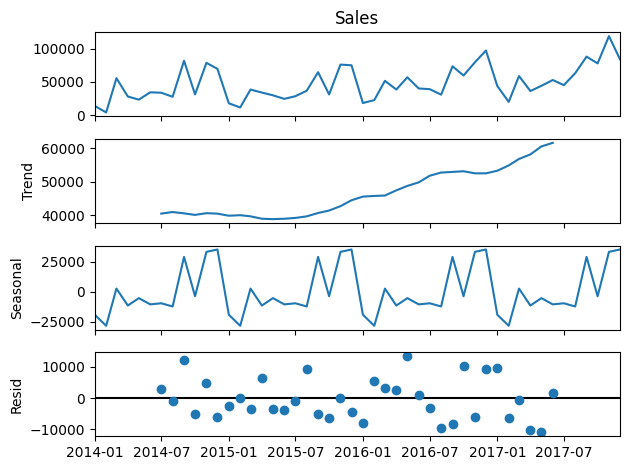

In [12]:
# Visualisation de la saisonnalité
plt.figure(figsize=(12, 6))
decomposition = seasonal_decompose(df_monthly['Sales'], model='additive')
decomposition.plot()
plt.show()

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

# Définir la taille du jeu de test (dernière année : 12 mois)
train_df = df_monthly.iloc[:-12]
test_df = df_monthly.iloc[-12:]

print(f"Taille du train: {len(train_df)}")
print(f"Taille du test: {len(test_df)}")

Taille du train: 36
Taille du test: 12


In [14]:
# 1. Modèle de Régression Linéaire (Baseline)
X_train = train_df[['Time_Index']]
y_train = train_df['Sales']
X_test = test_df[['Time_Index']]
y_test = test_df['Sales']

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

test_df = test_df.copy()
test_df['LR_Forecast'] = lr_model.predict(X_test)

In [15]:
# Modèle Holt-Winters (Saisonnier)
# On utilise une tendance additive et une saisonnalité additive
hw_model = ExponentialSmoothing(train_df['Sales'], trend='add', seasonal='add', seasonal_periods=12).fit()

test_df['HW_Forecast'] = hw_model.forecast(12)

# Affichage des premières prévisions
display(test_df[['Sales', 'LR_Forecast', 'HW_Forecast']])

,Sales,LR_Forecast,HW_Forecast
Order Date,,,
2017-01-01,43971.3740,60660.681815,33011.925449
2017-02-01,20301.1334,61591.310854,31277.866087
2017-03-01,58872.3528,62521.939894,65135.932126
2017-04-01,36521.5361,63452.568933,53340.103018
2017-05-01,44261.1102,64383.197973,58750.540158
2017-06-01,52981.7257,65313.827012,53249.784932
2017-07-01,45264.4160,66244.456051,55946.419675
2017-08-01,63120.8880,67175.085091,55886.947679
2017-09-01,87866.6520,68105.714130,97885.096600


Régression Linéaire - RMSE: 23664.50, MAE: 19663.55
Holt-Winters - RMSE: 12541.12, MAE: 11453.32


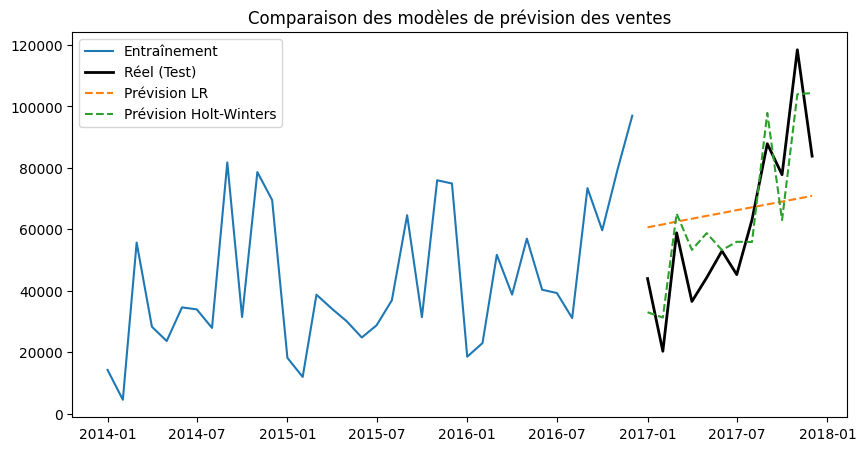

In [20]:
# Évaluation des performances
def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label} - RMSE: {rmse:.2f}, MAE: {mae:.2f}")

evaluate(test_df['Sales'], test_df['LR_Forecast'], "Régression Linéaire")
evaluate(test_df['Sales'], test_df['HW_Forecast'], "Holt-Winters")

# Visualisation finale
plt.figure(figsize=(10, 5))
plt.plot(train_df.index, train_df['Sales'], label='Entraînement')
plt.plot(test_df.index, test_df['Sales'], label='Réel (Test)', color='black', lw=2)
plt.plot(test_df.index, test_df['LR_Forecast'], label='Prévision LR', linestyle='--')
plt.plot(test_df.index, test_df['HW_Forecast'], label='Prévision Holt-Winters', linestyle='--')
plt.title('Comparaison des modèles de prévision des ventes')
plt.legend()
plt.show()

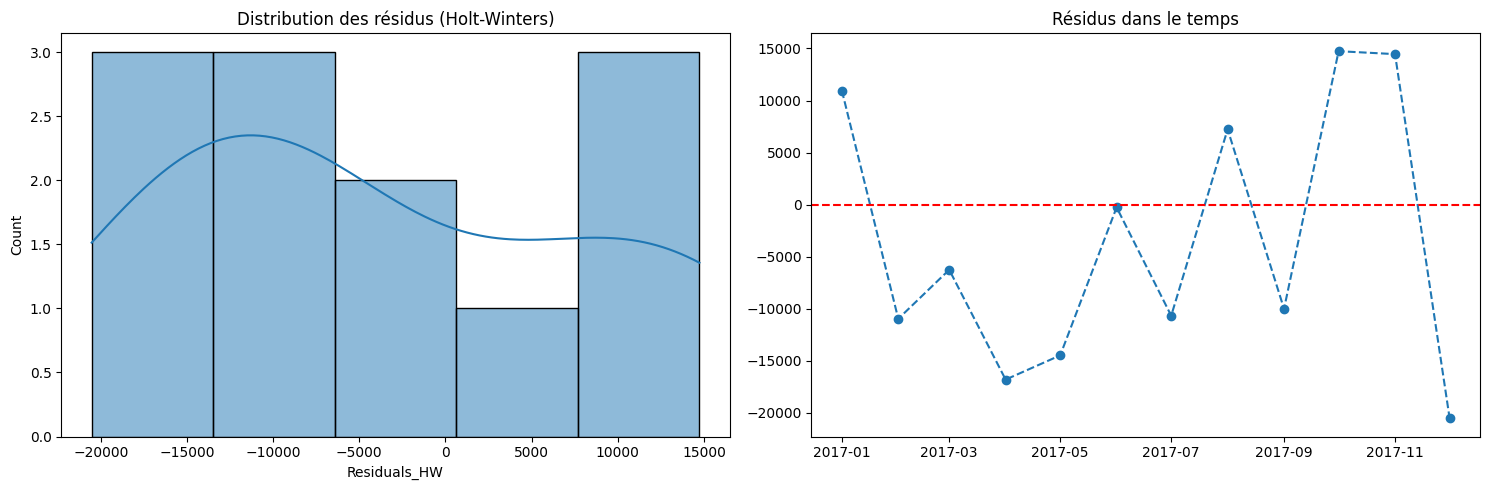

In [17]:
# Analyse des résidus pour Holt-Winters (le modèle le plus complexe)
test_df['Residuals_HW'] = test_df['Sales'] - test_df['HW_Forecast']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Distribution des résidus
sns.histplot(test_df['Residuals_HW'], kde=True, ax=ax1)
ax1.set_title('Distribution des résidus (Holt-Winters)')

# Résidus au cours du temps
ax2.plot(test_df.index, test_df['Residuals_HW'], marker='o', linestyle='--')
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title('Résidus dans le temps')

plt.tight_layout()
plt.show()

In [18]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = []
for model_name in ['LR_Forecast', 'HW_Forecast']:
    y_true = test_df['Sales']
    y_pred = test_df[model_name]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({
        'Modèle': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    })

df_results = pd.DataFrame(results)
display(df_results)

,Modèle,RMSE,MAE,MAPE (%)
0,LR_Forecast,23664.502794,19663.551639,44.406508
1,HW_Forecast,12541.121395,11453.320919,22.586474


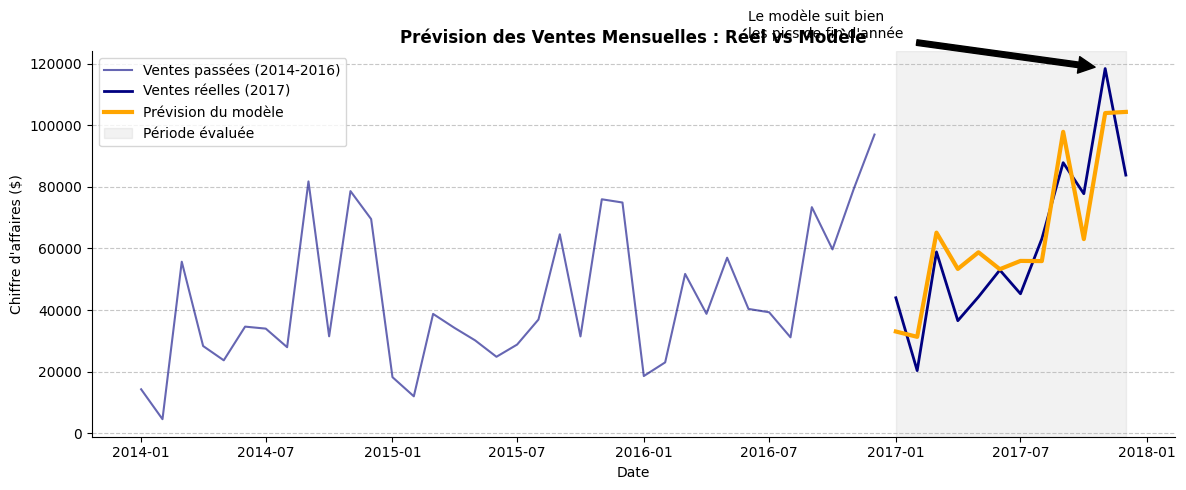

In [21]:
plt.figure(figsize=(12, 5))

# Tracer l'historique
plt.plot(train_df.index, train_df['Sales'], color='navy', label='Ventes passées (2014-2016)', alpha=0.6)

# Tracer la réalité vs prévision sur la zone de test
plt.plot(test_df.index, test_df['Sales'], color='navy', lw=2, label='Ventes réelles (2017)')
plt.plot(test_df.index, test_df['HW_Forecast'], color='orange', lw=3, label='Prévision du modèle')

# Mettre en évidence la zone de prévision
plt.axvspan(test_df.index[0], test_df.index[-1], color='gray', alpha=0.1, label='Période évaluée')

# Esthétique simplifiée
plt.title('Prévision des Ventes Mensuelles : Réel vs Modèle', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=10)
plt.ylabel('Chiffre d\'affaires ($)', fontsize=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=10)

# Annotations pour plus de clarté
max_val = test_df['Sales'].max()
plt.annotate('Le modèle suit bien\nles pics de fin d\'année',
             xy=(pd.Timestamp('2017-11-01'), max_val),
             xytext=(pd.Timestamp('2016-06-01'), max_val+10000),
             arrowprops=dict(facecolor='black', shrink=0.05))

sns.despine()
plt.tight_layout()
plt.show()

## Cette prévision est une technique qui utilise des données historiques pour estimer les résultats futurs. J'ai utilisé le modèle Holt-Winters, qui analyse la tendance et la saisonnalité pour prédire les ventes.

## **Gestion des stocks** : Anticiper les pics de ventes permet de s'assurer que les produits sont disponibles sans surstocker inutilement le reste de l'année

## **Budgétisation** : Estimer le chiffre d'affaires futur aide à planifier les investissements, les dépenses marketing et les embauches

## **Optimisation de la chaîne logistique** : En prévoyant les volumes de commandes, l'entreprise peut négocier de meilleurs tarifs avec les transporteurs ou ajuster ses capacités de livraison

## **Stratégie Commerciale** : Si le modèle prévoit une baisse de régime sur un trimestre, l'entreprise peut lancer des promotions ciblées pour compenser cet écart.